In [60]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import pandas as pd
from torchsummary import summary
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import time
import math
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter

In [61]:
torch.manual_seed(0)
np.random.seed(0)

In [62]:
INPUT_WINDOW = 20 # number of input steps
output_window = 5 # number of prediction steps, in this model its fixed to one
block_len = INPUT_WINDOW + output_window # for one input-output pair
batch_size = 64
TRAIN_SIZE = 0.8
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_FEATURES = 5
WRITE_TO_TENSORBOARD = False
SHUFFLE = True
RUN_NAME = f"testing_{INPUT_WINDOW}_outwin_{output_window}_1000_epochs"
SCALE_DATA = True


In [63]:
def modified_create_inout_sequences(input_data, INPUT_WINDOW ,output_window):
    in_seq = []
    out_seq = []
    L = len(input_data)
    block_num =  L - block_len + 1
    # where block_len = INPUT_WINDOW + output_window
    for i in range( block_num ):
        # if input_data.iloc[i]["vid_id"] == input_data.iloc[i + INPUT_WINDOW - 1]["vid_id"]:
        train_seq = input_data[i : i + INPUT_WINDOW]
        train_label = input_data[i + output_window : i + INPUT_WINDOW + output_window][-output_window:]
        in_seq.append(train_seq )
        out_seq.append(train_label)
    # print(torch.FloatTensor(np.array(in_seq)), torch.FloatTensor(np.array(out_seq)))
    return torch.FloatTensor(np.array(in_seq)), torch.FloatTensor(np.array(out_seq))

In [64]:
EXERCISE = "squat"
SLICE = "yes"
def get_data():
    import yfinance as yf
    df = yf.download("HINDUNILVR.NS", period="5y", progress=True)
    df.columns = df.columns.droplevel(1)
    df.columns = df.columns.get_level_values(0)
    df.columns.name = None
    df = df.reset_index()
    df = df[["Open", "High", "Low", "Close", "Volume"]]
    # angles=pd.read_csv(r"data\new_pushup.csv")
    scaler = MinMaxScaler(feature_range=(0, 1))
    # angles_to_scale = angles.iloc[:,2:]
    fitted_scaler = scaler.fit(df)
    scaled_data = pd.DataFrame(fitted_scaler.transform(df))
    # # scaled_angles = angles
    # if SCALE_DATA == True:
    #     angles = pd.concat([angles.iloc[:,0:2].reset_index(drop=True), scaled_angles.reset_index(drop=True)], axis=1)
    x_sequences, y_sequences = modified_create_inout_sequences(scaled_data, INPUT_WINDOW, output_window)
    # print(x_sequences.shape, y_sequences.shape)
        # shuffling sequences
    if SHUFFLE == True:
        shuffled_indices = torch.randperm(x_sequences.size(0))
        x_sequences = x_sequences[shuffled_indices]
        y_sequences = y_sequences[shuffled_indices]

    # x_sequences = x_sequences[:,:,2:] # remove the redundant columns
    # y_sequences = y_sequences[:,:,2:]
    samples = int(len(x_sequences) * TRAIN_SIZE) # use a parameter to control training size

    x_train = x_sequences[:samples]
    y_train = y_sequences[:samples]
    x_test = x_sequences[samples:]
    y_test = y_sequences[samples:]
    

    return x_train.to(device), y_train.to(device), x_test.to(device), y_test.to(device), fitted_scaler

x_train, y_train, x_test, y_test, scaler= get_data()

[*********************100%***********************]  1 of 1 completed


In [65]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

(torch.Size([971, 20, 5]),
 torch.Size([971, 5, 5]),
 torch.Size([243, 20, 5]),
 torch.Size([243, 5, 5]))

In [66]:
class MyNN(nn.Module):
    
    def __init__(self, num_classes=7, input_size=7, hidden_size=64, num_layers=2):
        super().__init__()
        # self.flatten = nn.Flatten()
        self.linera_relu_stack = nn.Sequential(
            nn.Linear(7, 512),
            nn.ReLU(),
            nn.Linear(512,512),
            nn.ReLU(),
            nn.Linear(512,7)
        )

    def forward(self, x):
        # x = self.flatten(x)
        logits = self.linera_relu_stack(x)
        return logits
    
# model = LSTM().to(device)
# summary(model, (10,7))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Assuming the input has a sequence length of 10 and input size of 7
sequence_length = 10
input_size = 7
model = MyNN().to(device)
summary(model, (batch_size, sequence_length, input_size))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1          [-1, 64, 10, 512]           4,096
              ReLU-2          [-1, 64, 10, 512]               0
            Linear-3          [-1, 64, 10, 512]         262,656
              ReLU-4          [-1, 64, 10, 512]               0
            Linear-5            [-1, 64, 10, 7]           3,591
Total params: 270,343
Trainable params: 270,343
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.02
Forward/backward pass size (MB): 10.03
Params size (MB): 1.03
Estimated Total Size (MB): 11.08
----------------------------------------------------------------


In [67]:
input_window = INPUT_WINDOW
class LSTMModel(nn.Module):
    def __init__(self, input_window, output_window, num_features, batch_size, device):
        super().__init__()
        self.input_window = input_window
        self.output_window = output_window
        self.num_features = num_features
        
        # LSTM layers
        self.lstm1 = nn.LSTM(input_size=num_features, 
                            hidden_size=64, 
                            num_layers=1, 
                            batch_first=True)
        
        self.lstm2 = nn.LSTM(input_size=num_features, 
                            hidden_size=48, 
                            num_layers=1, 
                            batch_first=True)
        
        # Fully connected layers
        self.fc1 = nn.Linear(input_window * 64, 512)
        self.fc2 = nn.Linear(512, input_window * num_features)
        self.fc3 = nn.Linear(output_window* 48, output_window * num_features)
        
        # Additional layers
        self.flatten = nn.Flatten()
        self.dropout1 = nn.Dropout(0.3)
        self.dropout2 = nn.Dropout(0.3)
        self.relu = nn.ReLU()
        self.conv = nn.Conv1d(in_channels=input_window, 
                             out_channels=output_window, 
                             kernel_size=3, 
                             padding=1)
        
    def forward(self, x):
        # First LSTM layer
        x, (h_n1, c_n1) = self.lstm1(x)
        x = self.flatten(x)
        
        # First fully connected section
        x = self.dropout1(x)
        x = self.fc1(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        
        # Reshape and second LSTM
        x = x.view(-1, self.input_window, self.num_features)
        x, (h_n2, c_n2) = self.lstm2(x)
        
        # Convolutional layer
        x = self.conv(x)
        x = self.flatten(x)
        # print(x.shape)
        
        # Final fully connected layer and reshape
        x = self.fc3(x)
        x = x.view(-1, self.output_window, self.num_features)
        
        return x

lstm_model = LSTMModel(INPUT_WINDOW, output_window, NUM_FEATURES, batch_size, device).to(device)
# sample_input = torch.randn(batch_size,input_window, NUM_FEATURES).to(device) # input should be (batch_size, seq_len(input_window(t)), num_features)
# output = lstm_model(sample_input)
# output
# summary(lstm_model, (batch_size, sequence_length, input_size))




In [68]:
MODEL = lstm_model
if WRITE_TO_TENSORBOARD == True:

    # Set a unique name for your run
    log_dir = f"runs/{RUN_NAME}"

    # Initialize SummaryWriter with the custom log directory
    writer = SummaryWriter(log_dir=log_dir, comment="1000 epoch financial")
    writer.add_graph(lstm_model, torch.rand([batch_size,INPUT_WINDOW, NUM_FEATURES]))

In [69]:
def r2_loss(output, target):
    target_mean = torch.mean(target)
    ss_tot = torch.sum((target - target_mean) ** 2)
    ss_res = torch.sum((target - output) ** 2)
    r2 = 1 - ss_res / ss_tot
    # print("sstot={:3.3f} | ssres={:3.3f} | r2={:3.3f}".format(ss_tot,ss_res, r2))
    return 1 - r2

In [70]:
def get_batch_modified(input_data_x, input_data_y, i, batch_size):
    batch_len = min(batch_size, len(input_data_x) - i)
    # Extract the input and target tensors from the batch
    x_data = input_data_x[i:i + batch_len]
    y_data = input_data_y[i:i + batch_len]
    
    return x_data, y_data

In [71]:
optimizer = torch.optim.AdamW(MODEL.parameters(), lr=1e-3)
loss_fn = nn.HuberLoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1, gamma=1)

In [72]:
def evaluate(eval_model, x_test, y_test, eval_batch_size):
    eval_model.eval() # Turn on the evaluation mode
    total_loss = 0.
    with torch.no_grad():
        # for i in range(0, len(data_source) - 1, eval_batch_size): # Now len-1 is not necessary
        for i in range(0, len(x_test), eval_batch_size):
            data, targets = get_batch_modified(x_test, y_test, i,eval_batch_size)
            output = eval_model(data)
            # print(output.shape)            
            # print(targets.shape)            
            total_loss += len(data[0]) * loss_fn(output, targets).cpu().item()
            # total_loss += len(data[0]) * r2_loss(output, targets).cpu().item()
    return total_loss / len(x_test)

In [73]:
def get_batch_modified(input_data_x, input_data_y, i, batch_size):
    batch_len = min(batch_size, len(input_data_x) - i)
    # Extract the input and target tensors from the batch
    x_data = input_data_x[i:i + batch_len]
    y_data = input_data_y[i:i + batch_len]
    
    return x_data, y_data

In [74]:
def predict_future(eval_model, x_test, y_test, steps):
    eval_model.eval() 
    total_loss = 0.
    test_result = torch.Tensor(0)    
    truth = torch.Tensor(0)
    data, _ = get_batch_modified(x_test, y_test, 0 , 1)
    with torch.no_grad():
        for i in range(0, steps):            
            # print(f"shape of data in preditct_future is {data.shape}")
            output = eval_model(data[-INPUT_WINDOW:])
            # print(f"shape of output in preditct_future is {output.shape}")
            data = torch.cat((data[:,output_window:,:], output[-1:]), dim=1)

            # print(data)

    data = data.cpu().view(-1)

In [75]:
def train_modified(model, x_train, y_train, optimizer, loss_fn, epoch):
    model.train()
    start_time = time.time()
    total_loss = 0
    for batch, i in enumerate(range(0, len(x_train), batch_size)):  # Now len-1 is not necessary
        data, targets = get_batch_modified(x_train, y_train, i , batch_size)
        # print(data.shape, targets.shape)
        # print(data.shape, targets.shape)
        # print(data[...,1:].shape)
        optimizer.zero_grad()
        # output = model(data)
        output = model(data)
        loss = loss_fn(output, targets)
        # loss = r2_loss(output, targets)
        if WRITE_TO_TENSORBOARD == True:
            writer.add_scalar("loss", loss, epoch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        log_interval = int(len(x_train) / batch_size / 5)
        if batch % log_interval == 0 and batch > 0:
            # print(f"loss.item = {loss.item()}")
            cur_loss = total_loss / log_interval
            elapsed = time.time() - start_time
            print('| epoch {:3d} | {:5d}/{:5d} batches | '
                  'lr {:02.6f} | {:5.2f} ms | '
                  'loss {:5.5f} | ppl {:8.4f}'.format(
                    epoch, batch, len(x_train) // batch_size, scheduler.get_lr()[0],
                    elapsed * 1000 / log_interval,
                    cur_loss, math.exp(cur_loss)))
            # print('| epoch {:3d} | {:5d}/{:5d} batches | '
            #       'lr {:02.6f} | {:5.2f} ms | '
            #       'loss {:5.5f}'.format(
            #         epoch, batch, len(train_data) // batch_size, scheduler.get_lr()[0],
            #         elapsed * 1000 / log_interval,
            #         loss.item()))
            total_loss = 0
            start_time = time.time()
        # break


In [76]:
x_train.shape

torch.Size([971, 20, 5])

In [77]:
epochs = 100
for epoch in range(1, epochs + 1):
    epoch_start_time = time.time()
    train_modified(x_train=x_train, y_train=y_train, optimizer=optimizer, loss_fn=loss_fn, epoch=epoch, model=MODEL)
    if ( epoch % 5 == 0 ):
        predict_future(MODEL, x_test, y_test, batch_size)
    else:
        val_loss = evaluate(MODEL, x_test, y_test, batch_size)
   
    print('-' * 89)
    print('| end of epoch {:3d} | time: {:5.2f}s | valid loss {:5.5f} | valid ppl {:8.2f}'.format(epoch, (time.time() - epoch_start_time),
                                     val_loss, math.exp(val_loss)))
    # print('| end of epoch {:3d} | time: {:5.2f}s | valid loss {:5.5f}'.format(epoch, (time.time() - epoch_start_time),
    #                                  val_loss))
    print('-' * 89)
    if WRITE_TO_TENSORBOARD == True:
        writer.add_scalar("val_loss", val_loss, epoch)
        
    scheduler.step()

c:\Users\HP\anaconda3\envs\fin-proj\Lib\site-packages\torch\optim\lr_scheduler.py:523: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)


| epoch   1 |     3/   15 batches | lr 0.001000 | 120.22 ms | loss 0.11843 | ppl   1.1257
| epoch   1 |     6/   15 batches | lr 0.001000 | 18.18 ms | loss 0.05040 | ppl   1.0517
| epoch   1 |     9/   15 batches | lr 0.001000 | 14.00 ms | loss 0.02157 | ppl   1.0218
| epoch   1 |    12/   15 batches | lr 0.001000 | 13.67 ms | loss 0.01523 | ppl   1.0153
| epoch   1 |    15/   15 batches | lr 0.001000 | 12.84 ms | loss 0.01304 | ppl   1.0131
-----------------------------------------------------------------------------------------
| end of epoch   1 | time:  0.56s | valid loss 0.00375 | valid ppl     1.00
-----------------------------------------------------------------------------------------
| epoch   2 |     3/   15 batches | lr 0.001000 | 24.36 ms | loss 0.01600 | ppl   1.0161
| epoch   2 |     6/   15 batches | lr 0.001000 | 15.00 ms | loss 0.01458 | ppl   1.0147
| epoch   2 |     9/   15 batches | lr 0.001000 | 14.84 ms | loss 0.01275 | ppl   1.0128
| epoch   2 |    12/   15 batch

In [85]:
inp, targets = get_batch_modified(x_train, y_train, 52, batch_size)
output = MODEL(inp)
tinp, ttargets, toutput = inp.transpose(1,2), targets.transpose(1,2), output.transpose(1,2)
scaler.inverse_transform(targets[0].cpu().numpy())[0], scaler.inverse_transform(output[0].detach().cpu().numpy())[0]

(array([2.3974585e+03, 2.4501089e+03, 2.3943560e+03, 2.4175784e+03,
        1.6100540e+06], dtype=float32),
 array([2.4145137e+03, 2.4398047e+03, 2.3886221e+03, 2.4108232e+03,
        1.7497885e+06], dtype=float32))

In [79]:
x_train.shape, y_train.shape

(torch.Size([971, 20, 5]), torch.Size([971, 5, 5]))

In [86]:
# scaler.inverse_transform(targets[0])[0:10,0], scaler.inverse_transform(output[0].detach().numpy())[0:10,0]

In [27]:
mse_loss = nn.MSELoss()
my_loss = mse_loss(output, targets)
my_loss
# when loss==mse(0.427): r2 = 0.8624 -8919 

tensor(0.0003, grad_fn=<MseLossBackward0>)

In [28]:
# plt.plot(train_data)

Text(0.5, 1.0, 'prediction within train_data')

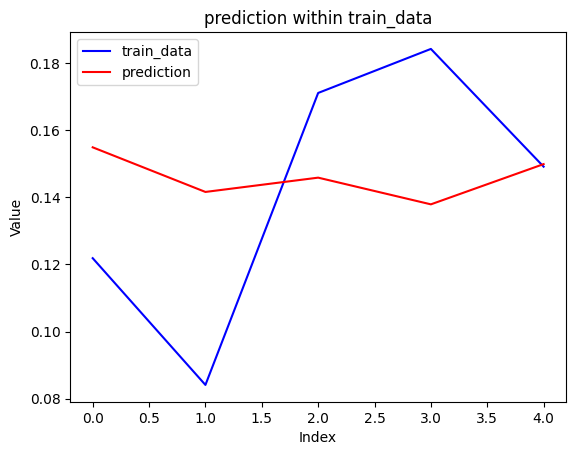

In [84]:

# Plot the entire train_data
pred_batch_num = 12
col_id = 4
# concat_data = torch.cat((tinp[pred_batch_num][col_id], ttargets[pred_batch_num][col_id]), dim=0)
plt.plot(ttargets[pred_batch_num][col_id].cpu().numpy(), label='train_data', color='blue')
# plt.plot(concat_data, label='train_data', color='blue')

# Highlight the subset
plt.plot(toutput[pred_batch_num][col_id].detach().cpu().numpy(), label='prediction', color='red')

# Additional plot settings
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.title('prediction within train_data')

In [208]:
if WRITE_TO_TENSORBOARD == True:
    !tensorboard --logdir=runs

^C


In [149]:
!tensorboard --logdir==runs

^C


In [209]:
MODEL.lstm1.flatten_parameters()
MODEL.lstm2.flatten_parameters()

In [2]:
import torch
model_scripted = torch.jit.script(MODEL) # Export to TorchScript
model_scripted.save('model_path/fin_ohlc_1000.pt') # Save

NameError: name 'MODEL' is not defined

In [35]:
# model = torch.jit.load('model_situp_scripted.pt')
# model.eval()

In [211]:
total_params = sum(p.numel() for p in MODEL.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 725,457


In [5]:
import torch
model = torch.jit.load('model_path/fin_ohlc_1000.pt')
MODEL = model
MODEL.eval()

RecursiveScriptModule(
  original_name=LSTMModel
  (lstm1): RecursiveScriptModule(original_name=LSTM)
  (lstm2): RecursiveScriptModule(original_name=LSTM)
  (fc1): RecursiveScriptModule(original_name=Linear)
  (fc2): RecursiveScriptModule(original_name=Linear)
  (fc3): RecursiveScriptModule(original_name=Linear)
  (flatten): RecursiveScriptModule(original_name=Flatten)
  (dropout1): RecursiveScriptModule(original_name=Dropout)
  (dropout2): RecursiveScriptModule(original_name=Dropout)
  (relu): RecursiveScriptModule(original_name=ReLU)
  (conv): RecursiveScriptModule(original_name=Conv1d)
)

In [36]:
inp, targets = get_batch_modified(x_train, y_train, 4, batch_size)
output = model(inp)
tinp, ttargets, toutput = inp.transpose(1,2), targets.transpose(1,2), output.transpose(1,2)
scaler.inverse_transform(targets[0].cpu().numpy())[0], scaler.inverse_transform(output[0].detach().cpu().numpy())[0]

(array([0.40437245, 0.4275489 , 0.43193352, 0.43357077], dtype=float32),
 array([0.40776056, 0.40216202, 0.42026561, 0.3982353 ], dtype=float32))

In [ ]:
import torch
import numpy as np

# 1. Get the Raw 2D Data (Shape: 20, 4)
raw_2d_input = df.iloc[-20:][columns_to_scale].values

# 2. Scale it WHILE IT IS STILL 2D
# Result is still (20, 4)
scaled_2d_input = scaler.transform(raw_2d_input)

# 3. NOW convert to 3D for the Model
# We convert to tensor first, then add the batch dimension
input_tensor = torch.tensor(raw_2d_input).float()
input_tensor = input_tensor.unsqueeze(0)  # Shape becomes (1, 20, 4)

# --- VERIFICATION ---
print(f"Shape for Scaler: {raw_2d_input.shape}")   # Should be (20, 4)
print(f"Shape for Model:  {input_tensor.shape}")   # Should be (1, 20, 4)

# 4. Run Inference
model.eval()
with torch.no_grad():
    output = model(input_tensor)

# 5. Inverse Transform the Output
# The output might be 3D or 2D depending on your model.
# If output is (1, 4) or (1, 1, 4), we must force it back to 2D for the scaler.

output_2d = output.cpu().numpy().reshape(-1, 4) # Forces it to be (N, 4)
real_prediction = scaler.inverse_transform(output_2d)

print("Predicted Price:", real_prediction)

Shape for Scaler: (20, 4)
Shape for Model:  torch.Size([1, 20, 4])
Predicted Price: [[0.4400848  0.4322721  0.45524627 0.42904505]
 [0.4426955  0.42956033 0.45468152 0.42952853]
 [0.43921292 0.43588114 0.45391464 0.43160465]
 [0.4432938  0.43966737 0.45871162 0.42894092]
 [0.44237742 0.4405598  0.45689276 0.43422264]]


In [40]:
real_prediction

array([[0.4400848 , 0.4322721 , 0.45524627, 0.42904505],
       [0.4426955 , 0.42956033, 0.45468152, 0.42952853],
       [0.43921292, 0.43588114, 0.45391464, 0.43160465],
       [0.4432938 , 0.43966737, 0.45871162, 0.42894092],
       [0.44237742, 0.4405598 , 0.45689276, 0.43422264]], dtype=float32)

In [ ]:
"""
1. give prediction charts to kaka
2. take volume as an input
3. output must be risk
"""

In [36]:
# # to be used for later use
# import os
# import pandas as pd
# from torchvision.io import read_image
# from torch.utils.data import Dataset

# class CustomImageDataset(Dataset):
#     def __init__(self, EXERCISE, annotations_file="data/labels.csv", data_file="data/angles.csv", SLICE="no", transform="yes"):
#         self.labels = pd.read_csv(annotations_file)
#         self.angles = pd.read_csv(data_file)
#         # self.data_file = data_file
#         if SLICE == "yes":
#             self.labels = self.labels[self.labels["class"]==EXERCISE]
#             self.angles = self.angles[self.angles["vid_id"].isin(self.labels["vid_id"])]
#         if transform == "yes":
#             scaler = MinMaxScaler(feature_range=(0, 1))
#             self.angles1 = self.angles.drop(["vid_id","frame_order"], axis=1)
#             self.tangles = scaler.fit_transform(self.angles1)

#     def __len__(self):
#         return len(self.angles)

#     def __getitem__(self, idx):
#         img_path = os.path.join(self.data_file, self.labels.iloc[idx, 0])
#         image = read_image(img_path)
#         label = self.labels.iloc[idx, 1]
#         if self.transform:
#             image = self.transform(image)
#         if self.target_transform:
#             label = self.target_transform(label)
#         return image, label